El objetivo de este análisis es realizar una análisis exploratorio mñás exhaustivo de los datos una vez se tiene un dataset con todos los datos a utilizar.

In [7]:
import pandas as pd

df = pd.read_parquet('../data/processed/dataset_solar_2023_2024_v1.parquet')
df.head()

,fecha,ano,mes,dia,hora,minuto,ghi,dni,dhi,elevacion_solar,temperatura,velocidad_viento,direccion_viento,humedad_relativa,codigo_ghi,codigo_dni,codigo_dhi
0,2023-01-01 00:00:00,2023,1,1,0,0,0.0,0.0,0.0,0.0,10.0,1.050,117.750,77.0,0,0,0
1,2023-01-01 00:01:00,2023,1,1,0,1,0.0,0.0,0.0,0.0,10.0,1.333,311.500,77.0,0,0,0
2,2023-01-01 00:02:00,2023,1,1,0,2,0.0,0.0,0.0,0.0,10.0,1.100,256.417,77.0,0,0,0
3,2023-01-01 00:03:00,2023,1,1,0,3,0.0,0.0,0.0,0.0,10.0,1.333,290.417,77.0,0,0,0
4,2023-01-01 00:04:00,2023,1,1,0,4,0.0,0.0,0.0,0.0,10.0,1.058,333.667,77.0,0,0,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1052640 entries, 0 to 1052639
Data columns (total 17 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   fecha             1052640 non-null  datetime64[us]
 1   ano               1052640 non-null  int64         
 2   mes               1052640 non-null  int64         
 3   dia               1052640 non-null  int64         
 4   hora              1052640 non-null  int64         
 5   minuto            1052640 non-null  int64         
 6   ghi               1040772 non-null  float64       
 7   dni               1040772 non-null  float64       
 8   dhi               1040772 non-null  float64       
 9   elevacion_solar   1052640 non-null  float64       
 10  temperatura       957464 non-null   float64       
 11  velocidad_viento  957464 non-null   float64       
 12  direccion_viento  957464 non-null   float64       
 13  humedad_relativa  957464 non-null   float64       
 1

Se tiene un dataset con más de 1 millón de mediciones y 16 variables a priori, de las cuáles se tienen 3 targets que indican la correcta medición de las irradancias GHI, DNI y DHI. Excepto la variable 'fecha', todas las variables son de tipo int o float. Existen nulos en algunas features relacionadas con irradancias o situación meteorológica, siendo estas últimas las que tienen más nulos con casi 80000 nulos.

In [9]:
numeric_columns = ['ghi', 'dni', 'dhi', 'elevacion_solar', 'temperatura', 'velocidad_viento', 'direccion_viento', 'humedad_relativa']

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
ghi,1040772.0,178.272834,285.576990,0.0,0.000,0.000000,293.800000,2525.500000
dni,1040772.0,228.888275,341.553291,0.0,0.000,0.000000,537.917000,1083.250000
dhi,1040772.0,70.152911,135.608487,0.0,0.000,0.000000,80.636000,1153.000000
elevacion_solar,1052640.0,16.126797,21.204923,0.0,0.000,0.452718,29.988567,76.031723
temperatura,957464.0,19.952180,7.900019,-50.0,14.200,19.370000,25.125000,43.450000
velocidad_viento,957464.0,1.909278,1.414230,0.0,0.933,1.627000,2.608000,19.442000
direccion_viento,957464.0,178.340605,97.672695,0.0,74.250,199.083000,248.750000,355.000000
humedad_relativa,957464.0,57.306242,22.061682,0.0,39.917,59.083000,76.000000,95.000000


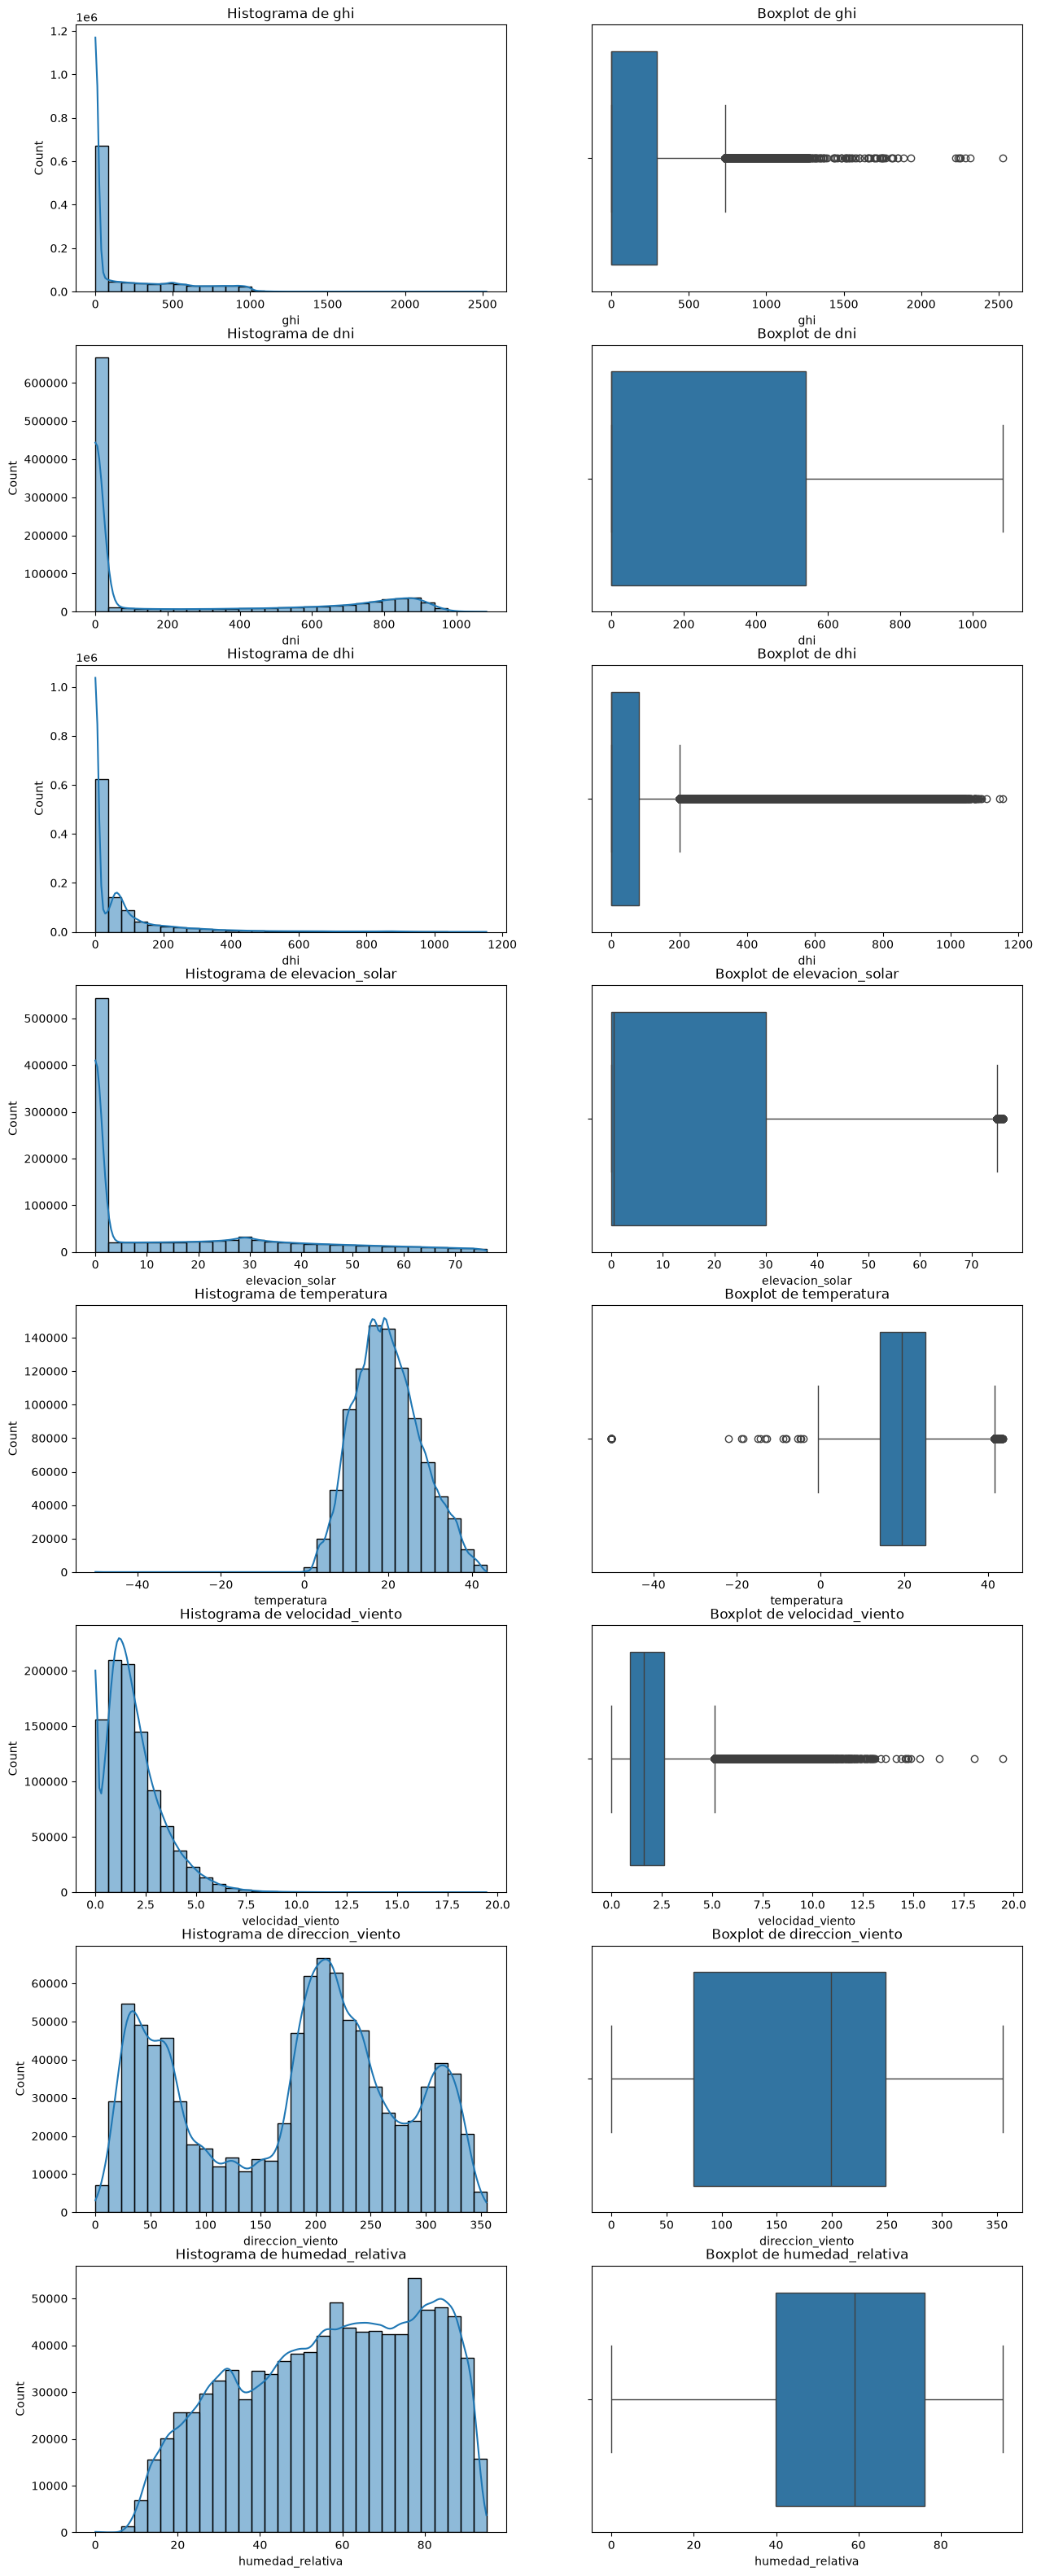

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_hist_box(df, numeric_columns):
    plt.figure(figsize=(15, 50))
    count = 1

    for col in numeric_columns:
        plt.subplot(len(numeric_columns), 2, count)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Histograma de {col}')
        count += 1

        plt.subplot(len(numeric_columns), 2, count)
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot de {col}')
        count += 1

plot_hist_box(df, numeric_columns)

## Comentarios sobre las variables

* **Irradiancias (`ghi`, `dni` y `dhi`)**: se concentran muchos valores en cero, algo normal por la presencia de registros nocturnos. Durante el día aparecen valores mucho más altos, especialmente en la `dni`. Destacan algunos máximos de `ghi` y `dhi`, ya que parecen poco habituales, por lo que deberían estar asociados a códigos de malos registros.

* **Elevación solar**: también acumula muchos valores cercanos a cero, en línea con las horas nocturnas o con momentos próximos al amanecer y al atardecer. Esto se debe principalmente a que se han establecido como valores nulos valores negativos de elevación del Sol.

* **Temperatura**: sigue una distribución bastante equilibrada y centrada en valores templados. El mínimo de −50 °C destaca claramente y probablemente sea un error de medida o un valor usado para indicar datos ausentes.

* **Velocidad del viento**: predominan las velocidades bajas, aunque hay algunos episodios de viento fuerte que generan una cola hacia valores altos.

* **Dirección del viento**: aparecen varias direcciones dominantes. Al tratarse de una variable circular, es mejor analizarla con una rosa de los vientos que con un boxplot o una media convencional.

* **Humedad relativa**: la mayor parte de los registros se sitúa en niveles medios y altos. Los valores cercanos a cero son poco habituales y sería conveniente revisarlos.

En general, antes de trabajar con los datos podría convenir separar día y noche usando la elevación solar, revisar los valores extremos y estudiar los datos ausentes, especialmente en las variables meteorológicas.


In [12]:
df_2023 = df[df['ano'] == 2023].copy()
df_2024 = df[df['ano'] == 2024].copy()

targets = ['codigo_ghi', 'codigo_dni', 'codigo_dhi']

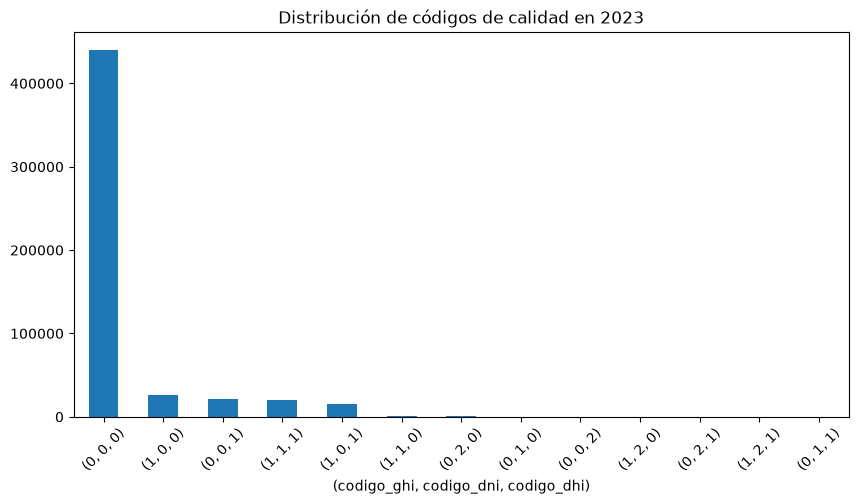

In [27]:
df_2023[targets].value_counts().plot(kind='bar', figsize=(10, 5), title='Distribución de códigos de calidad en 2023')
plt.xlabel('(codigo_ghi, codigo_dni, codigo_dhi)')
plt.xticks(rotation=45)
plt.show()

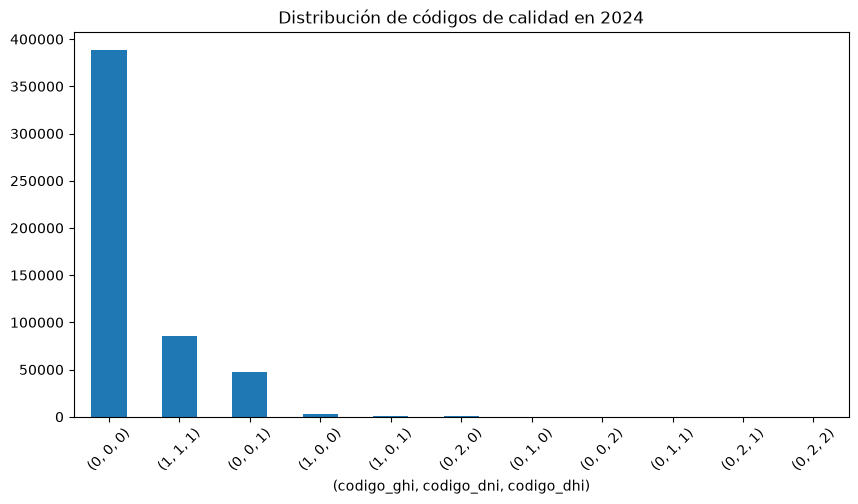

In [28]:
df_2024[targets].value_counts().plot(kind='bar', figsize=(10, 5), title='Distribución de códigos de calidad en 2024')
plt.xlabel('(codigo_ghi, codigo_dni, codigo_dhi)')
plt.xticks(rotation=45)
plt.show()

## Códigos de calidad de las medidas

En ambos años predominan claramente los registros con código **(0, 0, 0)**, por lo que la mayor parte de las medidas de `ghi`, `dni` y `dhi` se consideran correctas y coherentes entre sí.

En **2023** la calidad general es mejor, ya que la proporción de combinaciones con irregularidades es relativamente baja. Los casos más frecuentes después de los datos correctos afectan solo a una componente, sobre todo a la `ghi` o a la `dhi`, mientras que las combinaciones con varios errores simultáneos son poco habituales.

En **2024** disminuye el número de registros completamente correctos y aumentan de forma clara las combinaciones con código 1. Destaca especialmente **(1, 1, 1)**, lo que indica más periodos en los que las tres componentes presentan irregularidades al mismo tiempo. También aumenta **(0, 0, 1)**, asociado a problemas aislados en la `dhi`.

Los códigos relacionados con sombras, identificados con el valor **2**, tienen una presencia muy reducida en ambos años. Por tanto, las anomalías parecen estar más relacionadas con fallos de captación, mantenimiento, desconexiones o medidas inconsistentes que con sombras producidas por una baja elevación solar.
